In [ ]:
# ==============================
# 📦 IMPORTS (MODEL TRAINING)
# ==============================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# Display settings
pd.set_option('display.max_columns', None)

# ==============================
# 📂 LOAD CLEAN DATA
# ==============================
df = pd.read_csv("prepared.csv", parse_dates=["datetime"])

print("✅ Data loaded for Model Training")
display(df.head())

✅ Data loaded for Model Training


,year,month,day,hour,temp,dew_point,wet_bulb,rel_humidity,spec_humidity,pressure,wind_speed,wind_dir,precipitation,datetime,storm
0,2014,11,1,0,24.92,21.53,23.23,81.41,16.01,100.76,4.97,37.2,0.0,2014-11-01 00:00:00,0
1,2014,11,1,1,24.77,21.40,23.09,81.53,15.90,100.69,4.96,35.8,0.0,2014-11-01 01:00:00,0
2,2014,11,1,2,24.67,21.30,22.98,81.56,15.82,100.63,4.94,34.8,0.0,2014-11-01 02:00:00,0
3,2014,11,1,3,24.55,21.23,22.89,81.77,15.75,100.61,4.93,34.1,0.0,2014-11-01 03:00:00,0
4,2014,11,1,4,24.44,21.16,22.80,82.07,15.70,100.62,4.97,33.2,0.0,2014-11-01 04:00:00,0


In [ ]:
# ==============================
# 📦 IMPORTS (ML)
# ==============================
from sklearn.model_selection import train_test_split

# Features & Target
X = df[[
    "spec_humidity",
    "dew_point",
    "rel_humidity",
    "pressure",
    "wet_bulb",
    "wind_speed"
]]

y = df["storm"]

# Train-test split (STRATIFIED IMPORTANT)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (64300, 6)
Test shape: (16076, 6)


##Train All Models

In [ ]:
# ==============================
# 🤖 MODEL TRAINING
# ==============================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!
Gradient Boosting trained successfully!


##Evaluation Metrics

In [ ]:
# ==============================
# 📊 MODEL EVALUATION
# ==============================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
2        Random Forest  0.913536   0.641732  0.304483  0.413007  0.890710
1        Decision Tree  0.873352   0.375145  0.402242  0.388221  0.663940
3    Gradient Boosting  0.909679   0.642066  0.216687  0.324022  0.879801
0  Logistic Regression  0.906196   0.722727  0.099004  0.174151  0.853067


##Confusion Matrix

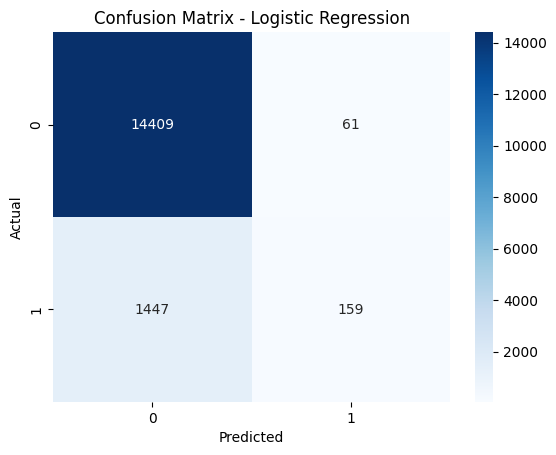

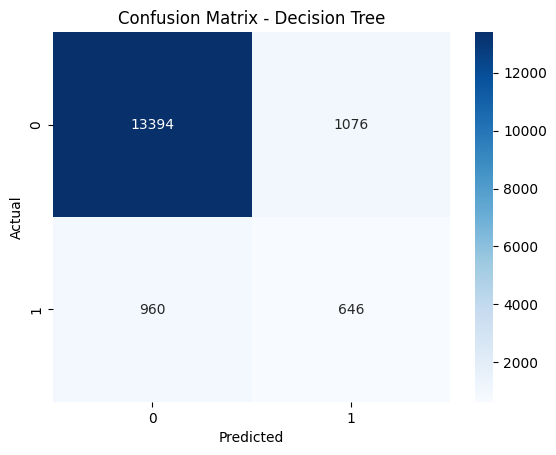

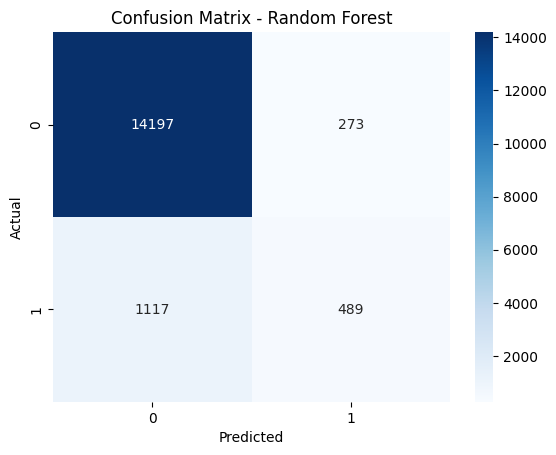

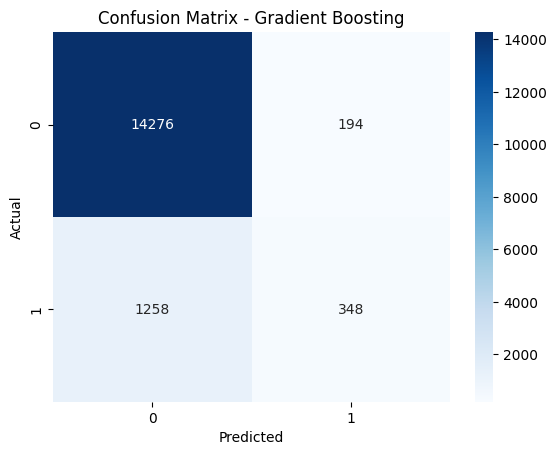

In [ ]:
from sklearn.metrics import confusion_matrix

for name, model in trained_models.items():
    plt.figure()
    cm = confusion_matrix(y_test, model.predict(X_test))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

##ROC Curve

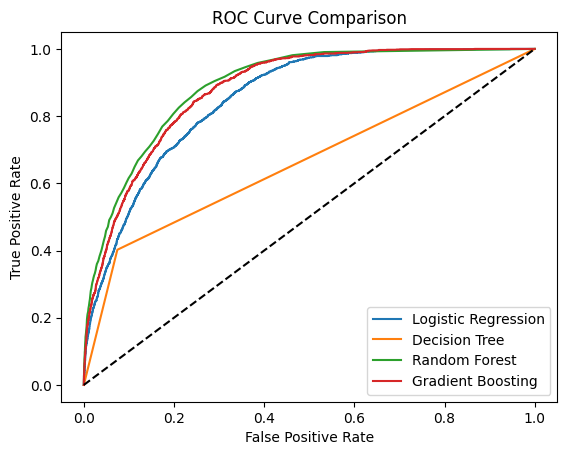

In [ ]:
from sklearn.metrics import roc_curve

plt.figure()

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()